In [16]:
import xml.etree.ElementTree as ET

from dm_control.suite.utils import randomizers
import collections
from dm_control.utils import io as resources
from dm_control.suite import base, common
from dm_control import mujoco, viewer, suite
from dm_control.rl import control
import numpy as np
from dm_env import specs

In [17]:
TASKS = [('reach_top_left', np.array([-0.15, 0.15, 0.01])),
         ('reach_top_right', np.array([0.15, 0.15, 0.01])),
         ('reach_bottom_left', np.array([-0.15, -0.15, 0.01])),
         ('reach_bottom_right', np.array([0.15, -0.15, 0.01]))]


class MultiTaskPointMassMaze(base.Task):
    """A point_mass `Task` to reach target with smooth reward."""
    def __init__(self, target_id, random=None):
        """Initialize an instance of `PointMassMaze`.

    Args:
      randomize_gains: A `bool`, whether to randomize the actuator gains.
      random: Optional, either a `numpy.random.RandomState` instance, an
        integer seed for creating a new `RandomState`, or None to select a seed
        automatically (default).
    """
        self._target = TASKS[target_id][1]
        super().__init__(random=random)

    def initialize_episode(self, physics):
        """Sets the state of the environment at the start of each episode.

       If _randomize_gains is True, the relationship between the controls and
       the joints is randomized, so that each control actuates a random linear
       combination of joints.

    Args:
      physics: An instance of `mujoco.Physics`.
    """
        randomizers.randomize_limited_and_rotational_joints(
            physics, self.random)
        physics.data.qpos[0] = np.random.uniform(0.0, 0.0)
        physics.data.qpos[1] = np.random.uniform(0.0, 0.0)
        
        #import ipdb; ipdb.set_trace()
        # physics.named.data.geom_xpos['target'][:] = self._target
        

        super().initialize_episode(physics)

    def get_observation(self, physics):
        """Returns an observation of the state."""
        obs = collections.OrderedDict()
        obs['position'] = physics.position()
        obs['velocity'] = physics.velocity()
        return obs
    
    def get_reward_spec(self):
        return specs.Array(shape=(1,), dtype=np.float32, name='reward')

    def get_reward(self, physics):
        """Returns a reward to the agent."""
        return 0



class Physics(mujoco.Physics):
    """physics for the point_mass domain."""

    def mass_to_target_dist(self, target):
        """Returns the distance from mass to the target."""
        d = target - self.named.data.geom_xpos['pointmass']
        return np.linalg.norm(d)


In [238]:
# HARDEST_MAZE_TEST = [
#     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
#     [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
#     [1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1],
#     [1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
#     [1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1],
#     [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
#     [1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1],
#     [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
#     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
# ]

HARDEST_MAZE_TEST = [
    # [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 1],
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    # [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
]

maze = HARDEST_MAZE_TEST


# [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
# [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
# [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
# [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
# [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
# [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
# [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],

maze_optim = [
    # (x, y, h, w)
    (1, 1, 1, 2),    
    (0, 4, 2, 1),
    (3, 1, 1, 4),
    (5, 0, 1, 1),
    (4, 2, 3, 1),
    (1, 6, 3, 1),
    (4, 4, 2, 1),
    (5, 6, 2, 1),
    (1, 8, 1, 1),
    (3, 7, 1, 2),
    (5, 8, 1, 2)
]

In [239]:
# tree = ET.parse('mazes/empty.xml')
# worldbody = tree.find(".//worldbody")


# block_size = 0.025


# height, width = block_size*len(maze), block_size*len(maze[0])

# torso_x, torso_y = width - block_size, height - block_size

# # <geom name="ground" type="plane" pos="0 0 0" size=".3 .3 .1" material="grid"/>
# # <geom name="wall_x" type="plane" pos="-.3 0 .02" zaxis="1 0 0"  size=".02 .3 .02" material="decoration"/>
# # <geom name="wall_y" type="plane" pos="0 -.3 .02" zaxis="0 1 0"  size=".3 .02 .02" material="decoration"/>
# # <geom name="wall_neg_x" type="plane" pos=".3 0 .02" zaxis="-1 0 0"  size=".02 .3 .02" material="decoration"/>
# # <geom name="wall_neg_y" type="plane" pos="0 .3 .02" zaxis="0 -1 0"  size=".3 .02 .02" material="decoration"/>


# ET.SubElement(worldbody, "geom", {"name": "ground", "type": "plane", "pos": "0 0 0", "size": f"{width} {height} .1", "material": "grid"})
# ET.SubElement(worldbody, "geom", {"name": "wall_x", "type": "plane", "pos": f"-{width} 0 .02", "zaxis": "1 0 0", "size": f".02 {height} .02",  "material": "decoration"})
# ET.SubElement(worldbody, "geom", {"name": "wall_y", "type": "plane", "pos": f"0 -{height} .02", "zaxis": "0 1 0", "size": f"{width} .02 .02", "material": "decoration"})
# ET.SubElement(worldbody, "geom", {"name": "wall_neg_x", "type": "plane", "pos": f"{width} 0 .02", "zaxis": "-1 0 0", "size": f".02 {height} .02",  "material": "decoration"})
# ET.SubElement(worldbody, "geom", {"name": "wall_neg_y", "type": "plane", "pos": f"0 {height} .02", "zaxis": "0 -1 0", "size": f"{width} .02 .02", "material": "decoration"})


# for i in range(len(maze)):
#     for j in range(len(maze[0])):
#         struct = maze[i][j]
#         if struct == 1:  # Unmovable block.

#             attr = {
#                 "name": "block_%d_%d" % (i, j),
#                 "pos": "%f %f %f" % (j * block_size * 2 - torso_x,
#                                     i * block_size *2 - torso_y,
#                                     0.02),
#                 "size": "%f %f %f" % (block_size, block_size, 0.02),
#                 "class": "wall"
#             }
#             ET.SubElement(worldbody, "geom", attr)
#             print(attr['pos'])
            
#         # break
#     # break
    
# tree.write('./mazes/test.xml')

In [305]:
len(maze), len(maze[0])

(7, 10)

In [309]:
torso_x, torso_y

(0.225, 0.15000000000000002)

In [317]:
height, width = block_size*len(maze), block_size*len(maze[0])

torso_x, torso_y = width - block_size, height - block_size

height, width, len(maze), len(maze[0])

(0.17500000000000002, 0.25, 7, 10)

In [312]:
tree = ET.parse('mazes/empty.xml')
worldbody = tree.find(".//worldbody")


block_size = 0.025


height, width = block_size*len(maze), block_size*len(maze[0])

torso_x, torso_y = width - block_size, height - block_size


ET.SubElement(worldbody, "geom", {"name": "ground", "type": "plane", "pos": "0 0 0", "size": f"{width} {height} .1", "material": "grid"})
ET.SubElement(worldbody, "geom", {"name": "wall_x", "type": "plane", "pos": f"-{width} 0 .02", "zaxis": "1 0 0", "size": f".02 {height} .02",  "material": "decoration"})
ET.SubElement(worldbody, "geom", {"name": "wall_y", "type": "plane", "pos": f"0 -{height} .02", "zaxis": "0 1 0", "size": f"{width} .02 .02", "material": "decoration"})
ET.SubElement(worldbody, "geom", {"name": "wall_neg_x", "type": "plane", "pos": f"{width} 0 .02", "zaxis": "-1 0 0", "size": f".02 {height} .02",  "material": "decoration"})
ET.SubElement(worldbody, "geom", {"name": "wall_neg_y", "type": "plane", "pos": f"0 {height} .02", "zaxis": "0 -1 0", "size": f"{width} .02 .02", "material": "decoration"})


for i in range(len(maze_optim)):
    (y, x, w, h) = maze_optim[i]

    print(x * block_size * 2,  torso_x, (h - 1) * block_size)
    attr = {
        "name": "block_%d" % (i),
        "pos": "%f %f %f" % (x * block_size * 2 - torso_x + (h - 1) * block_size,
                             y * block_size * 2 - torso_y + (w - 1) * block_size,
                            0.02),
        "size": "%f %f %f" % (h * block_size, w * block_size, 0.02),
        "class": "wall"
    }
    ET.SubElement(worldbody, "geom", attr)
    print(attr['pos'])
                
tree.write('./mazes/test.xml')

0.05 0.225 0.025
-0.150000 -0.100000 0.020000
0.2 0.225 0.0
-0.025000 -0.125000 0.020000
0.05 0.225 0.07500000000000001
-0.100000 0.000000 0.020000
0.0 0.225 0.0
-0.225000 0.100000 0.020000
0.1 0.225 0.0
-0.125000 0.100000 0.020000
0.30000000000000004 0.225 0.0
0.075000 -0.050000 0.020000
0.2 0.225 0.0
-0.025000 0.075000 0.020000
0.30000000000000004 0.225 0.0
0.075000 0.125000 0.020000
0.4 0.225 0.0
0.175000 -0.100000 0.020000
0.35000000000000003 0.225 0.025
0.150000 0.000000 0.020000
0.4 0.225 0.025
0.200000 0.100000 0.020000


In [296]:
torso_x, torso_y

(0.225, 0.15000000000000002)

In [307]:
xml = resources.GetResource(f'mazes/test.xml')
# xml = resources.GetResource(f'mazes/point_mass_maze_empty.xml')
physics = Physics.from_xml_string(xml, common.ASSETS)
task = MultiTaskPointMassMaze(0)

dm_env = control.Environment(
    physics,
    task,
    time_limit=20,
)

viewer.launch(dm_env)

---

1 1 1 2
0 4 2 1
3 1 1 4
5 0 1 1
4 2 3 1
1 6 3 1
4 4 2 1
5 6 2 1
1 8 1 1
3 7 1 2
5 8 1 2


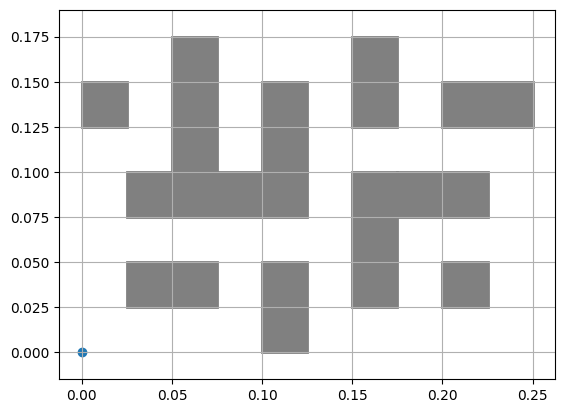

In [293]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


maze_optim = [
    # (x, y, h, w)
    (1, 1, 1, 2),    
    (0, 4, 2, 1),
    (3, 1, 1, 4),
    (5, 0, 1, 1),
    (4, 2, 3, 1),
    (1, 6, 3, 1),
    (4, 4, 2, 1),
    (5, 6, 2, 1),
    (1, 8, 1, 1),
    (3, 7, 1, 2),
    (5, 8, 1, 2)
]

# Get current axes
ax = plt.gca()

min_x, max_x, min_y, max_y = 10000, -10000, 10000, -10000
for i in range(len(maze_optim)):
    (x, y, h, w) = maze_optim[i]
    x = x * block_size
    y = y * block_size
    w = w * block_size
    h = h * block_size
    
    rect = patches.Rectangle((y, x), w, h, linewidth=2, edgecolor='gray', facecolor='gray')
    ax.add_patch(rect)

plt.axis('equal')
plt.grid(True, 'major')
plt.show()